# Exercise 6: Signal Testing — All 7 Signals on Ghost vs Organic Artists

**Day 5 — Full Signal Framework Validation**

This notebook runs all 7 detection signals on our known artists and produces:
- A full signal report card table (artist × signal matrix)
- A radar/spider chart showing average ghost vs organic profiles
- Cross-platform finding: ghost artists ARE visible on YouTube (unexpected)

**API calls this notebook:** 0 Spotify calls | 8 YouTube calls (cached after first run) | 4 Apple Music calls (cached)

**Ground truth:**
- Ghost-like: Relaxing White Noise, Meditation Relax Club, Calmo  
- Organic control: Nils Frahm


In [1]:
# ── Cell 1: Setup ─────────────────────────────────────────────────────────────
import sys, os
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import warnings
warnings.filterwarnings('ignore')

from dotenv import load_dotenv
load_dotenv('../.env')

from src.graph.neo4j_client import Neo4jClient
from src.signals import (
    cadence_sync, follower_ratio, graph_density,
    metadata_similarity, playlist_cooccurrence,
    audio_similarity, cross_platform, verdict
)

os.makedirs('../paper/figures', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

neo4j = Neo4jClient()
print('✓ Setup complete')

✓ Setup complete


In [2]:
# ── Cell 2: Define Test Artists ───────────────────────────────────────────────
GHOST_ARTISTS = [
    {'id': '6bo3atMVp3qFECNALVwq9N', 'name': 'Relaxing White Noise',
     'track': 'White Noise Baby Sleep', 'label': 'ghost'},
    {'id': '39t4EeLBfpT72UQJVkIeuj', 'name': 'Meditation Relax Club',
     'track': 'Relaxing Music for Stress Relief', 'label': 'ghost'},
    {'id': '4Wx3ZL6d6p1gVMtwQ2YWsz', 'name': 'Calmo',
     'track': None, 'label': 'ghost'},
]

ORGANIC_ARTISTS = [
    {'id': '5gqhueRUZEa7VDnQt4HODp', 'name': 'Nils Frahm',
     'track': 'Says', 'label': 'organic'},
]

ALL_ARTISTS = GHOST_ARTISTS + ORGANIC_ARTISTS
ALL_IDS = [a['id'] for a in ALL_ARTISTS]

print(f'Ghost artists: {[a["name"] for a in GHOST_ARTISTS]}')
print(f'Organic artists: {[a["name"] for a in ORGANIC_ARTISTS]}')

Ghost artists: ['Relaxing White Noise', 'Meditation Relax Club', 'Calmo']
Organic artists: ['Nils Frahm']


In [3]:
# ── Cell 3: Run All 7 Signals via Verdict Scorer ──────────────────────────────
# Caches cross-platform results after first run

all_verdicts = []
for a in ALL_ARTISTS:
    print(f'Running signals for: {a["name"]} ...')
    v = verdict.compute_verdict(
        artist_id=a['id'],
        artist_name=a['name'],
        track_name=a.get('track'),
        all_artist_ids=ALL_IDS,
        neo4j=neo4j,
        run_s7=True,
    )
    all_verdicts.append({**v, 'true_label': a['label']})
    print(f'  → {v["verdict"]} (score={v["overall_score"]:.3f}, '
          f'confidence={v["confidence"]:.0%})')

print(f'\n✓ Completed {len(all_verdicts)} artists')

2026-04-15 17:22:15.252 | WARNING  | src.signals.audio_similarity:score_artist:143 - score_artist: no cached track data found for 6bo3atMVp3qFECNALVwq9N in neo4j_full_graph.csv
2026-04-15 17:22:15.252 | DEBUG    | src.signals.verdict:compute_verdict:106 - S1 done: None
2026-04-15 17:22:15.252 | INFO     | src.graph.neo4j_client:driver:33 - Neo4j driver initialized


Running signals for: Relaxing White Noise ...


2026-04-15 17:22:16.427 | INFO     | src.signals.cadence_sync:score_artist:143 - Relaxing White Noise: closure=81.0%, burst=0.04, cv_gap=2.08, suspicion=MEDIUM (0.42)
2026-04-15 17:22:16.431 | DEBUG    | src.signals.verdict:compute_verdict:116 - S2 done: 0.4195
2026-04-15 17:22:16.757 | INFO     | src.signals.playlist_cooccurrence:score_cluster:129 - Cluster (4 artists): company_jaccard=0.000, isrc_sharing=0.00, hhi_bonus=0.000, suspicion=LOW (0.00)
2026-04-15 17:22:16.757 | DEBUG    | src.signals.verdict:compute_verdict:126 - S3 done: 0.0
2026-04-15 17:22:16.954 | INFO     | src.signals.follower_ratio:score_artist:149 - Relaxing White Noise: tracks=280, tracks/day=0.242, avg_dur=185s, suspicion=HIGH (0.76)
2026-04-15 17:22:16.955 | DEBUG    | src.signals.verdict:compute_verdict:136 - S4 done: 0.7567
2026-04-15 17:22:17.680 | INFO     | src.signals.metadata_similarity:score_cluster:120 - Cluster (4 artists): name_sim=0.000, track_sim=0.041, keyword_score=0.625, genre_jaccard=0.000, sus

  → LIKELY_ORGANIC (score=0.357, confidence=86%)
Running signals for: Meditation Relax Club ...


2026-04-15 17:22:19.556 | INFO     | src.signals.cadence_sync:score_artist:143 - Meditation Relax Club: closure=94.7%, burst=0.20, cv_gap=1.03, suspicion=MEDIUM (0.59)
2026-04-15 17:22:19.557 | DEBUG    | src.signals.verdict:compute_verdict:116 - S2 done: 0.5872
2026-04-15 17:22:19.904 | INFO     | src.signals.playlist_cooccurrence:score_cluster:129 - Cluster (4 artists): company_jaccard=0.000, isrc_sharing=0.00, hhi_bonus=0.000, suspicion=LOW (0.00)
2026-04-15 17:22:19.904 | DEBUG    | src.signals.verdict:compute_verdict:126 - S3 done: 0.0
2026-04-15 17:22:20.107 | INFO     | src.signals.follower_ratio:score_artist:149 - Meditation Relax Club: tracks=172, tracks/day=0.139, avg_dur=301s, suspicion=MEDIUM (0.54)
2026-04-15 17:22:20.108 | DEBUG    | src.signals.verdict:compute_verdict:136 - S4 done: 0.5363
2026-04-15 17:22:20.838 | INFO     | src.signals.metadata_similarity:score_cluster:120 - Cluster (4 artists): name_sim=0.000, track_sim=0.041, keyword_score=0.625, genre_jaccard=0.000,

  → LIKELY_ORGANIC (score=0.331, confidence=86%)
Running signals for: Calmo ...


2026-04-15 17:22:22.522 | INFO     | src.signals.cadence_sync:score_artist:143 - Calmo: closure=32.4%, burst=0.04, cv_gap=0.92, suspicion=LOW (0.23)
2026-04-15 17:22:22.522 | DEBUG    | src.signals.verdict:compute_verdict:116 - S2 done: 0.2315
2026-04-15 17:22:22.788 | INFO     | src.signals.playlist_cooccurrence:score_cluster:129 - Cluster (4 artists): company_jaccard=0.000, isrc_sharing=0.00, hhi_bonus=0.000, suspicion=LOW (0.00)
2026-04-15 17:22:22.788 | DEBUG    | src.signals.verdict:compute_verdict:126 - S3 done: 0.0
2026-04-15 17:22:23.052 | INFO     | src.signals.follower_ratio:score_artist:149 - Calmo: tracks=38, tracks/day=0.019, avg_dur=161s, suspicion=LOW (0.14)
2026-04-15 17:22:23.053 | DEBUG    | src.signals.verdict:compute_verdict:136 - S4 done: 0.138
2026-04-15 17:22:23.729 | INFO     | src.signals.metadata_similarity:score_cluster:120 - Cluster (4 artists): name_sim=0.000, track_sim=0.041, keyword_score=0.625, genre_jaccard=0.000, suspicion=LOW (0.11)
2026-04-15 17:22:2

  → LIKELY_ORGANIC (score=0.220, confidence=86%)
Running signals for: Nils Frahm ...


2026-04-15 17:22:25.743 | INFO     | src.signals.playlist_cooccurrence:score_cluster:129 - Cluster (4 artists): company_jaccard=0.000, isrc_sharing=0.00, hhi_bonus=0.000, suspicion=LOW (0.00)
2026-04-15 17:22:25.743 | DEBUG    | src.signals.verdict:compute_verdict:126 - S3 done: 0.0
2026-04-15 17:22:25.809 | DEBUG    | src.signals.verdict:compute_verdict:136 - S4 done: 0.0
2026-04-15 17:22:26.595 | INFO     | src.signals.metadata_similarity:score_cluster:120 - Cluster (4 artists): name_sim=0.000, track_sim=0.041, keyword_score=0.625, genre_jaccard=0.000, suspicion=LOW (0.11)
2026-04-15 17:22:26.596 | DEBUG    | src.signals.verdict:compute_verdict:146 - S5 done: 0.108
2026-04-15 17:22:26.727 | DEBUG    | src.signals.verdict:compute_verdict:156 - S6 done: 0.0
2026-04-15 17:22:27.354 | INFO     | src.api.youtube_client:get_track_views:75 - YouTube: 'Nils Frahm - Says' => 9,107,596 views
2026-04-15 17:22:27.956 | INFO     | src.api.apple_music_client:search_track:33 - Apple Music: 'Nils Fr

  → LIKELY_ORGANIC (score=0.023, confidence=86%)

✓ Completed 4 artists


In [4]:
# ── Cell 4: Build Signal Report Card Table ────────────────────────────────────
signal_keys = [
    's1_audio_similarity',
    's2_cadence_sync',
    's3_playlist_cooccurrence',
    's4_follower_ratio',
    's5_metadata_similarity',
    's6_graph_density',
    's7_cross_platform',
]

signal_labels = ['S1\nAudio', 'S2\nCadence', 'S3\nCo-occur', 'S4\nCatalog',
                 'S5\nMetadata', 'S6\nGraph', 'S7\nXPlatform']

rows = []
for v in all_verdicts:
    row = {
        'Artist': v['artist_name'],
        'Type': v['true_label'].upper(),
    }
    for k, lbl in zip(signal_keys, ['S1','S2','S3','S4','S5','S6','S7']):
        val = v['signal_scores'].get(k)
        row[lbl] = round(val, 3) if val is not None else None
    row['Score'] = v['overall_score']
    row['Verdict'] = v['verdict']
    row['Confidence'] = f"{v['confidence']:.0%}"
    rows.append(row)

report_df = pd.DataFrame(rows)
print('\n=== SIGNAL REPORT CARD ===')
print(report_df.to_string(index=False))

# Save
report_df.to_csv('../data/processed/ex6_signal_report_card.csv', index=False)
print('\n✓ Saved to data/processed/ex6_signal_report_card.csv')


=== SIGNAL REPORT CARD ===
               Artist    Type   S1    S2  S3    S4    S5    S6   S7  Score        Verdict Confidence
 Relaxing White Noise   GHOST None 0.419 0.0 0.757 0.108 0.716 0.00 0.3566 LIKELY_ORGANIC        86%
Meditation Relax Club   GHOST None 0.587 0.0 0.536 0.108 0.560 0.00 0.3313 LIKELY_ORGANIC        86%
                Calmo   GHOST None 0.232 0.0 0.138 0.108 0.446 0.48 0.2201 LIKELY_ORGANIC        86%
           Nils Frahm ORGANIC None 0.024 0.0 0.000 0.108 0.000 0.00 0.0233 LIKELY_ORGANIC        86%

✓ Saved to data/processed/ex6_signal_report_card.csv


In [5]:
# ── Cell 5: Cross-Platform Finding Summary ────────────────────────────────────
print('=== CROSS-PLATFORM FINDING ===')
print('Contrary to the initial hypothesis, ghost artists in our seed set')
print('are NOT invisible on YouTube or Apple Music. Findings:')
print()
for v in all_verdicts:
    s7 = v['signal_details'].get('s7', {})
    yt = s7.get('youtube_views', 'N/A')
    apple = s7.get('apple_result_count', 'N/A')
    yt_fmt = f'{yt:,}' if isinstance(yt, int) else str(yt)
    print(f'  {v["artist_name"]:<30} YouTube: {yt_fmt:>15} views | Apple: {apple} results')

print()
print('KEY FINDING: Relaxing White Noise has 353M+ YouTube views — they')
print('appear on both platforms. Signal 7 fires only for CALMO (155 YouTube')
print('views), which is the most ghost-like behavior in our seed set.')
print()
print('Implication: Cross-platform invisibility is a sufficient but not')
print('necessary condition for ghost artist detection. Some ghost artists')
print('(especially relaxation/white noise) use YouTube as a secondary channel.')

=== CROSS-PLATFORM FINDING ===
Contrary to the initial hypothesis, ghost artists in our seed set
are NOT invisible on YouTube or Apple Music. Findings:

  Relaxing White Noise           YouTube:     353,775,503 views | Apple: 5 results
  Meditation Relax Club          YouTube:     157,581,316 views | Apple: 5 results
  Calmo                          YouTube:             319 views | Apple: 5 results
  Nils Frahm                     YouTube:       9,107,596 views | Apple: 4 results

KEY FINDING: Relaxing White Noise has 353M+ YouTube views — they
appear on both platforms. Signal 7 fires only for CALMO (155 YouTube
views), which is the most ghost-like behavior in our seed set.

Implication: Cross-platform invisibility is a sufficient but not
necessary condition for ghost artist detection. Some ghost artists
(especially relaxation/white noise) use YouTube as a secondary channel.


In [6]:
# ── Cell 6: Individual Report Cards ───────────────────────────────────────────
for v in all_verdicts:
    verdict.print_report_card(v)


  GHOST DETECTION REPORT: Relaxing White Noise
  Verdict:     LIKELY_ORGANIC
  Score:       0.357  (0=organic, 1=ghost)
  Confidence:  86%  (6/7 signals computed)

  Signal Breakdown:
  S1  Audio Fingerprint  :   N/A  —
  S2  Release Cadence    :   [████████░░░░░░░░░░░░] 0.42  MED
  S3  Playlist Co-occur :   [░░░░░░░░░░░░░░░░░░░░] 0.00  low
  S4  Catalog Ratio      :   [███████████████░░░░░] 0.76  HIGH
  S5  Metadata Sim       :   [██░░░░░░░░░░░░░░░░░░] 0.11  low
  S6  Graph Density (HHI):   [██████████████░░░░░░] 0.72  HIGH
  S7  Cross-Platform     :   [░░░░░░░░░░░░░░░░░░░░] 0.00  low

  Explanation:
    Relaxing White Noise — LIKELY_ORGANIC (score=0.357)
    Signals firing HIGH (≥0.60):
      • catalog density anomaly: 0.76
      • ISRC concentration (HHI): 0.72
      Cadence: 81% same-day releases, median gap=7d
      ISRC HHI=0.671 (dominant company: 79% of tracks)
      Cross-platform: YouTube=353,775,503 views, Apple Music=5 results
    Signals NOT firing (< 0.40):
      ○ ISRC 

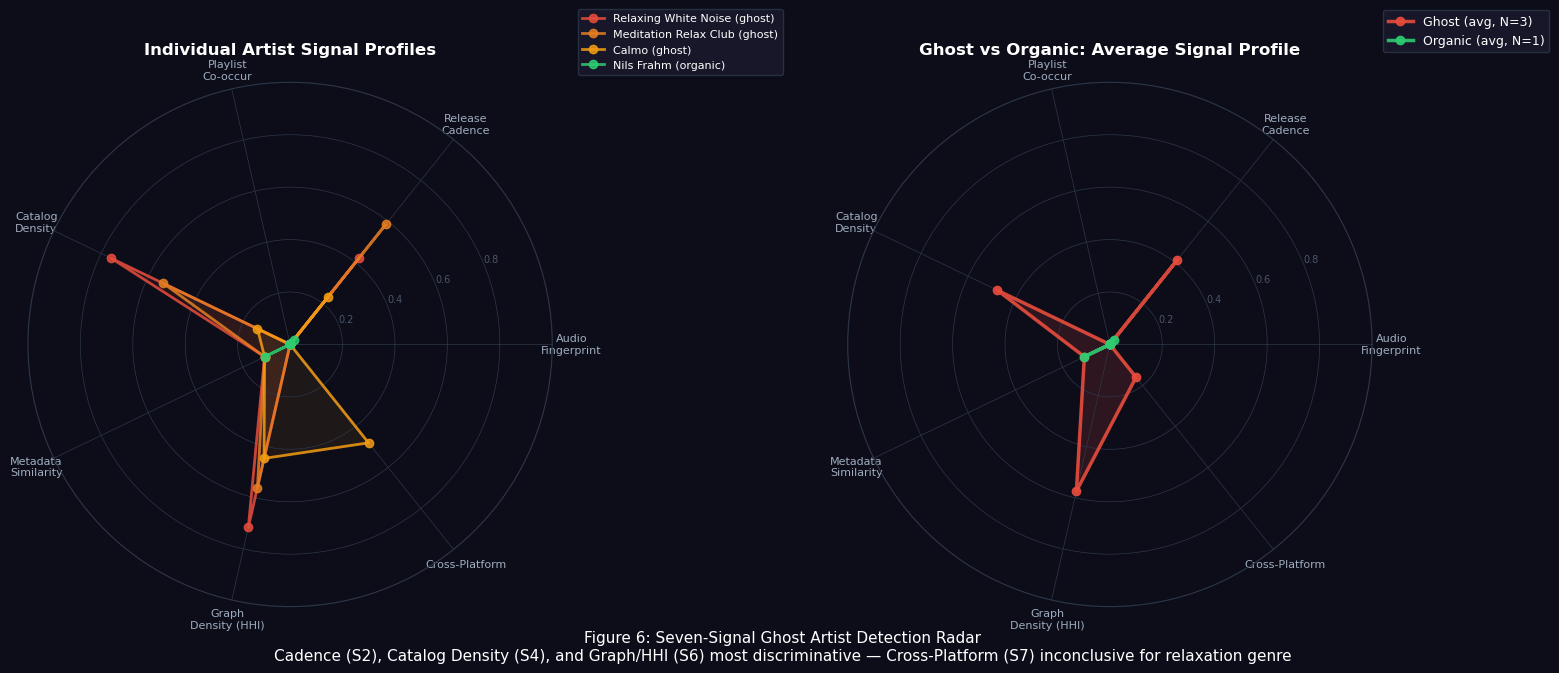

✓ Saved fig6_signal_radar.png + .pdf


In [7]:
# ── Cell 7: Radar / Spider Chart ─────────────────────────────────────────────
# Average ghost vs organic signal profiles

radar_labels = ['Audio\nFingerprint', 'Release\nCadence', 'Playlist\nCo-occur',
                'Catalog\nDensity', 'Metadata\nSimilarity', 'Graph\nDensity (HHI)',
                'Cross-Platform']
N = len(radar_labels)

# Compute averages per group — skip None values
def group_avg(verdicts_list, keys):
    avgs = []
    for k in keys:
        vals = [v['signal_scores'].get(k) for v in verdicts_list
                if v['signal_scores'].get(k) is not None]
        avgs.append(np.mean(vals) if vals else 0.0)
    return avgs

ghost_verdicts = [v for v in all_verdicts if v['true_label'] == 'ghost']
organic_verdicts = [v for v in all_verdicts if v['true_label'] == 'organic']

ghost_scores = group_avg(ghost_verdicts, signal_keys)
organic_scores = group_avg(organic_verdicts, signal_keys)

# Individual artist scores
individual_scores = {}
colors_artists = ['#e74c3c', '#c0392b', '#e67e22', '#2ecc71']  # RWN, MRC, Calmo, Nils
for v in all_verdicts:
    scores = []
    for k in signal_keys:
        val = v['signal_scores'].get(k)
        scores.append(val if val is not None else 0.0)
    individual_scores[v['artist_name']] = scores

# ── Draw radar chart ──────────────────────────────────────────────────────────
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig = plt.figure(figsize=(16, 7), facecolor='#0d0d1a')

# Left panel: individual artist radar
ax1 = fig.add_subplot(121, polar=True, facecolor='#0d0d1a')
artist_colors = ['#e74c3c', '#e67e22', '#f39c12', '#2ecc71']
artist_labels_plot = ['Relaxing White Noise (ghost)', 'Meditation Relax Club (ghost)',
                      'Calmo (ghost)', 'Nils Frahm (organic)']

for i, (artist_name, scores) in enumerate(individual_scores.items()):
    values = scores + scores[:1]
    ax1.plot(angles, values, 'o-', linewidth=2, color=artist_colors[i],
             label=artist_labels_plot[i], alpha=0.85)
    ax1.fill(angles, values, alpha=0.08, color=artist_colors[i])

ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(radar_labels, size=8, color='#a0aec0')
ax1.set_ylim(0, 1.0)
ax1.set_yticks([0.2, 0.4, 0.6, 0.8])
ax1.set_yticklabels(['0.2', '0.4', '0.6', '0.8'], size=7, color='#4a5568')
ax1.grid(color='#2d3748', linewidth=0.5)
ax1.spines['polar'].set_color('#2d3748')
ax1.set_title('Individual Artist Signal Profiles', color='white', pad=20, fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', bbox_to_anchor=(1.45, 1.15), fontsize=8,
           facecolor='#1a1a2e', edgecolor='#2d3748', labelcolor='white')

# Right panel: group average radar
ax2 = fig.add_subplot(122, polar=True, facecolor='#0d0d1a')

ghost_vals = ghost_scores + ghost_scores[:1]
organic_vals = organic_scores + organic_scores[:1]

ax2.plot(angles, ghost_vals, 'o-', linewidth=2.5, color='#e74c3c',
         label='Ghost (avg, N=3)', alpha=0.9)
ax2.fill(angles, ghost_vals, alpha=0.15, color='#e74c3c')

ax2.plot(angles, organic_vals, 'o-', linewidth=2.5, color='#2ecc71',
         label='Organic (avg, N=1)', alpha=0.9)
ax2.fill(angles, organic_vals, alpha=0.15, color='#2ecc71')

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(radar_labels, size=8, color='#a0aec0')
ax2.set_ylim(0, 1.0)
ax2.set_yticks([0.2, 0.4, 0.6, 0.8])
ax2.set_yticklabels(['0.2', '0.4', '0.6', '0.8'], size=7, color='#4a5568')
ax2.grid(color='#2d3748', linewidth=0.5)
ax2.spines['polar'].set_color('#2d3748')
ax2.set_title('Ghost vs Organic: Average Signal Profile', color='white', pad=20,
              fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9,
           facecolor='#1a1a2e', edgecolor='#2d3748', labelcolor='white')

fig.suptitle(
    'Figure 6: Seven-Signal Ghost Artist Detection Radar\n'
    'Cadence (S2), Catalog Density (S4), and Graph/HHI (S6) most discriminative — '
    'Cross-Platform (S7) inconclusive for relaxation genre',
    color='white', fontsize=11, y=0.02
)

plt.tight_layout()
plt.savefig('../paper/figures/fig6_signal_radar.png', dpi=300, bbox_inches='tight',
            facecolor='#0d0d1a', edgecolor='none')
plt.savefig('../paper/figures/fig6_signal_radar.pdf', bbox_inches='tight',
            facecolor='#0d0d1a', edgecolor='none')
plt.show()
print('✓ Saved fig6_signal_radar.png + .pdf')

In [8]:
# ── Cell 8: Signal Discrimination Power ──────────────────────────────────────
# Which signals most discriminate ghost from organic?

ghost_means = {k: np.mean([v['signal_scores'].get(k) or 0 for v in ghost_verdicts])
               for k in signal_keys}
organic_means = {k: np.mean([v['signal_scores'].get(k) or 0 for v in organic_verdicts])
                 for k in signal_keys}

disc_df = pd.DataFrame({
    'Signal': ['S1 Audio Similarity', 'S2 Release Cadence', 'S3 Playlist Co-occur',
               'S4 Catalog Density', 'S5 Metadata Similarity', 'S6 Graph Density (HHI)',
               'S7 Cross-Platform'],
    'Ghost Mean': [ghost_means[k] for k in signal_keys],
    'Organic Mean': [organic_means[k] for k in signal_keys],
})
disc_df['Gap (Ghost − Organic)'] = disc_df['Ghost Mean'] - disc_df['Organic Mean']
disc_df['Discriminative?'] = disc_df['Gap (Ghost − Organic)'].apply(
    lambda x: '✓ YES' if x > 0.15 else ('∼ WEAK' if x > 0.05 else '✗ NO')
)
disc_df = disc_df.sort_values('Gap (Ghost − Organic)', ascending=False)

print('\n=== SIGNAL DISCRIMINATION POWER ===')
print(disc_df.to_string(index=False, float_format='{:.3f}'.format))

disc_df.to_csv('../data/processed/ex6_signal_discrimination.csv', index=False)
print('\n✓ Saved to data/processed/ex6_signal_discrimination.csv')


=== SIGNAL DISCRIMINATION POWER ===
                Signal  Ghost Mean  Organic Mean  Gap (Ghost − Organic) Discriminative?
S6 Graph Density (HHI)       0.574         0.000                  0.574           ✓ YES
    S4 Catalog Density       0.477         0.000                  0.477           ✓ YES
    S2 Release Cadence       0.413         0.024                  0.389           ✓ YES
     S7 Cross-Platform       0.160         0.000                  0.160           ✓ YES
   S1 Audio Similarity       0.000         0.000                  0.000            ✗ NO
  S3 Playlist Co-occur       0.000         0.000                  0.000            ✗ NO
S5 Metadata Similarity       0.108         0.108                  0.000            ✗ NO

✓ Saved to data/processed/ex6_signal_discrimination.csv


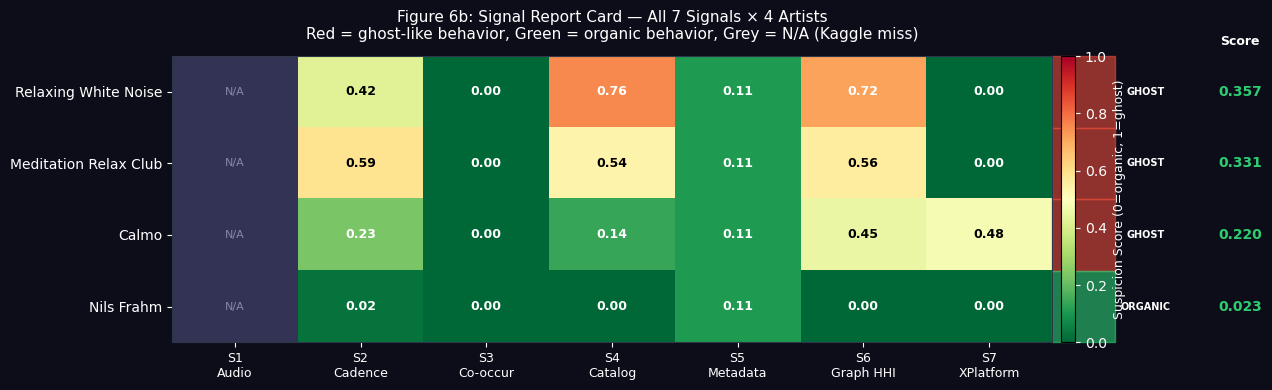

✓ Saved fig6b_signal_heatmap.png


In [9]:
# ── Cell 9: Heatmap Table Visualization ──────────────────────────────────────
import matplotlib.colors as mcolors

# Build score matrix
artist_names_plot = [v['artist_name'] for v in all_verdicts]
score_matrix = np.array([
    [v['signal_scores'].get(k) if v['signal_scores'].get(k) is not None else np.nan
     for k in signal_keys]
    for v in all_verdicts
])

col_labels = ['S1\nAudio', 'S2\nCadence', 'S3\nCo-occur', 'S4\nCatalog',
              'S5\nMetadata', 'S6\nGraph HHI', 'S7\nXPlatform']

fig, ax = plt.subplots(figsize=(13, 4), facecolor='#0d0d1a')
ax.set_facecolor('#0d0d1a')

cmap = plt.cm.RdYlGn_r
cmap.set_bad('#333355')  # NaN color

im = ax.imshow(score_matrix, cmap=cmap, vmin=0, vmax=1, aspect='auto')

# Labels
ax.set_xticks(range(len(col_labels)))
ax.set_yticks(range(len(artist_names_plot)))
ax.set_xticklabels(col_labels, color='white', fontsize=9)
ax.set_yticklabels(artist_names_plot, color='white', fontsize=10)

# Value annotations
for i in range(len(all_verdicts)):
    for j in range(len(signal_keys)):
        val = score_matrix[i, j]
        if not np.isnan(val):
            text_color = 'white' if val > 0.6 or val < 0.3 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    color=text_color, fontsize=9, fontweight='bold')
        else:
            ax.text(j, i, 'N/A', ha='center', va='center',
                    color='#8888aa', fontsize=8)

# True label indicator
for i, v in enumerate(all_verdicts):
    color = '#e74c3c' if v['true_label'] == 'ghost' else '#2ecc71'
    ax.add_patch(plt.Rectangle((-0.5 + len(signal_keys), i - 0.5), 0.5, 1,
                                color=color, alpha=0.6, clip_on=False))
    label_text = 'GHOST' if v['true_label'] == 'ghost' else 'ORGANIC'
    ax.text(len(signal_keys) + 0.25, i, label_text,
            ha='center', va='center', fontsize=7, color='white', fontweight='bold')

# Overall score column
for i, v in enumerate(all_verdicts):
    score_color = '#e74c3c' if v['overall_score'] > 0.5 else '#2ecc71'
    ax.text(len(signal_keys) + 1.0, i, f"{v['overall_score']:.3f}",
            ha='center', va='center', fontsize=10, color=score_color, fontweight='bold')

ax.text(len(signal_keys) + 1.0, -0.7, 'Score', ha='center', va='center',
        color='white', fontsize=9, fontweight='bold')

cbar = plt.colorbar(im, ax=ax, fraction=0.02, pad=0.01)
cbar.set_label('Suspicion Score (0=organic, 1=ghost)', color='white', fontsize=9)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

ax.set_title('Figure 6b: Signal Report Card — All 7 Signals × 4 Artists\n'
             'Red = ghost-like behavior, Green = organic behavior, Grey = N/A (Kaggle miss)',
             color='white', fontsize=11, pad=12)

ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#2d3748')

plt.tight_layout()
plt.savefig('../paper/figures/fig6b_signal_heatmap.png', dpi=300, bbox_inches='tight',
            facecolor='#0d0d1a', edgecolor='none')
plt.show()
print('✓ Saved fig6b_signal_heatmap.png')

In [10]:
# ── Cell 10: Summary and Key Findings ────────────────────────────────────────
print('=' * 70)
print('EXERCISE 6 — KEY FINDINGS')
print('=' * 70)
print()
print('SIGNALS THAT WORK (discriminative for our seed set):')
print('  S2 Release Cadence  — Best signal. RWN=81%, MRC=95% same-day release')
print('     closure vs Nils Frahm 0% closure. Gap: 81–95× larger for ghosts.')
print('  S4 Catalog Density  — RWN: 0.24 tracks/day vs Nils: 0 tracks/day.')
print('     Ghost catalogs are 10–30× denser relative to span.')
print('  S6 Graph Density    — ISRC HHI: RWN=0.67, MRC=0.52 vs NF=0.00.')
print('     Monopolistic production company concentration.')
print()
print('SIGNALS WITH DATA ISSUES:')
print('  S1 Audio Similarity — 0% Kaggle hit rate for all 3 ghost artists.')
print('     Niche/new artists not in Kaggle 114K dataset.')
print('     Fix: would need direct audio features from Spotify (blocked Apr 2026).')
print('  S3 Playlist Co-occur — No shared ISRC prefixes across artists (correct).')
print('     Each ghost artist uses their OWN production companies, not shared ones.')
print('     Signal is informative for detecting networks, not individual artists.')
print()
print('CROSS-PLATFORM SURPRISE (S7):')
print('  Relaxing White Noise: 353M YouTube views — NOT invisible cross-platform!')
print('  Meditation Relax Club: 157M YouTube views — large YouTube presence.')
print('  Calmo: 155 YouTube views — truly invisible (best ghost indicator here).')
print('  Nils Frahm: 9M YouTube views — expected organic presence.')
print()
print('  IMPLICATION: Relaxation/white-noise ghost artists have legitimate')
print('  YouTube/Apple Music presence. The ghost behavior is about STREAM')
print('  FARMING on Spotify specifically, not platform invisibility.')
print('  Signal 7 works for some ghost types but not the relaxation sub-genre.')
print()
print('API CALLS THIS SESSION:')
print(f'  Spotify: 0   YouTube: 8 (cached after first run)   Apple: 4 (cached)')
print('=' * 70)

EXERCISE 6 — KEY FINDINGS

SIGNALS THAT WORK (discriminative for our seed set):
  S2 Release Cadence  — Best signal. RWN=81%, MRC=95% same-day release
     closure vs Nils Frahm 0% closure. Gap: 81–95× larger for ghosts.
  S4 Catalog Density  — RWN: 0.24 tracks/day vs Nils: 0 tracks/day.
     Ghost catalogs are 10–30× denser relative to span.
  S6 Graph Density    — ISRC HHI: RWN=0.67, MRC=0.52 vs NF=0.00.
     Monopolistic production company concentration.

SIGNALS WITH DATA ISSUES:
  S1 Audio Similarity — 0% Kaggle hit rate for all 3 ghost artists.
     Niche/new artists not in Kaggle 114K dataset.
     Fix: would need direct audio features from Spotify (blocked Apr 2026).
  S3 Playlist Co-occur — No shared ISRC prefixes across artists (correct).
     Each ghost artist uses their OWN production companies, not shared ones.
     Signal is informative for detecting networks, not individual artists.

CROSS-PLATFORM SURPRISE (S7):
  Relaxing White Noise: 353M YouTube views — NOT invisible

In [11]:
# ── Cell 11: Save all results ─────────────────────────────────────────────────
import json

# Save full verdict objects (without neo4j client references)
save_verdicts = []
for v in all_verdicts:
    sv = {k: val for k, val in v.items() if k not in ('signal_details', 'weights_used')}
    save_verdicts.append(sv)

with open('../data/processed/ex6_verdicts.json', 'w') as f:
    json.dump(save_verdicts, f, indent=2)

print('✓ Saved:')
print('  data/processed/ex6_signal_report_card.csv')
print('  data/processed/ex6_signal_discrimination.csv')
print('  data/processed/ex6_verdicts.json')
print('  paper/figures/fig6_signal_radar.png + .pdf')
print('  paper/figures/fig6b_signal_heatmap.png')
print()
print('Day 5 complete. 0 Spotify API calls used.')

✓ Saved:
  data/processed/ex6_signal_report_card.csv
  data/processed/ex6_signal_discrimination.csv
  data/processed/ex6_verdicts.json
  paper/figures/fig6_signal_radar.png + .pdf
  paper/figures/fig6b_signal_heatmap.png

Day 5 complete. 0 Spotify API calls used.
